# Moral AI - New Approach (Scenario-Level)
We are switching from user-level aggregation to scenario-level prediction because we want to predict a new user's choice in a specific scenario, and aggregates remove scenario context and can leak target information.

## Section 1 - Load the Two Base Datasets

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

MM_PATH = Path("SharedResponsesSurvey.csv")
BRIDGE_PATH = Path("bridge.csv")
HF_DATASET_ID = "ecorbari/IPIP120-SCORES"

pd.set_option("display.max_columns", 50)


def load_personality_from_hf(dataset_id: str = HF_DATASET_ID) -> pd.DataFrame:
    """Load the first available split from a Hugging Face dataset."""
    ds = load_dataset(dataset_id)
    split = next(iter(ds.keys()))
    return ds[split].to_pandas()


if not MM_PATH.exists():
    raise FileNotFoundError(f"Missing file: {MM_PATH}")

# Dataset 1 preview
mm_head = pd.read_csv(MM_PATH, nrows=5)
mm_head

# Dataset 2 preview (Hugging Face)
df_ipip = load_personality_from_hf()
df_ipip.head()

c:\Users\ionel\Desktop\MoralAI-Predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,case,sex,age,sec,min,hour,day,month,year,country,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,...,facet_dutifulness,facet_achievement_striving,facet_self_discipline,facet_cautiousness,extraversion,facet_friendliness,facet_gregariousness,facet_assertiveness,facet_activity_level,facet_excitement_seeking,facet_cheerfulness,agreeableness,facet_trust,facet_morality,facet_altruism,facet_cooperation,facet_modesty,facet_sympathy,neuroticism,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability
0,1,2,19,8,41,16,30,6,101,South Afr,5,4,5,4,4,2,5,5,4,4,2,4,4,4,4,...,54.892857,63.675297,41.888264,84.032423,56.493023,74.071748,65.945007,77.299926,12.265075,23.740125,66.964675,84.214345,73.438475,72.159605,67.393775,76.776519,74.954334,77.384533,35.573367,27.993157,11.549711,58.018551,39.725121,96.864432,11.048211
1,2,2,22,24,45,16,30,6,101,USA,5,4,4,2,5,5,5,4,5,4,4,4,5,5,4,...,44.963610,16.580116,84.633574,67.456166,80.144284,77.267973,94.271135,47.536294,96.065024,87.511279,5.776425,47.158018,13.978142,83.405900,89.448233,4.270395,69.646885,67.981348,66.998550,58.854938,89.843818,89.880570,57.486716,1.000000,80.327511
2,6,1,13,14,6,17,30,6,101,USA,2,4,2,2,4,4,5,4,3,2,2,4,2,2,4,...,14.383704,80.885654,99.646135,74.813500,80.931850,70.526550,86.659049,39.758576,92.707965,73.646661,65.158443,1.000000,7.526992,7.408120,2.417954,3.278791,24.018170,12.400848,22.577376,33.979027,86.802916,29.000871,7.509259,6.890607,15.131043
3,7,2,18,25,11,17,30,6,101,USA,3,4,3,2,5,4,4,4,3,3,2,5,4,4,5,...,78.953690,82.391009,83.566408,60.403585,84.255079,74.071748,81.190659,96.180870,97.498896,23.740125,56.848582,44.246158,27.248015,72.159605,54.492760,52.320264,38.542547,41.268613,12.466800,12.195029,57.719898,18.108659,8.870845,44.831762,5.285188
4,8,2,24,19,25,17,30,6,101,USA,4,4,4,5,4,2,3,4,4,4,3,3,5,5,4,...,44.963610,16.580116,43.843893,42.280102,50.534797,49.513820,59.439053,37.789326,41.578470,22.776857,88.517103,77.026790,83.907554,58.955730,66.457831,82.330021,50.199377,55.939489,26.353107,21.800273,7.899414,26.475441,38.817649,62.697315,53.029251


## Section 2 - Explain the Switch in Approach (Notebook Context)
- Old workflow: aggregate all choices per user and predict a user-level moral profile.
- New workflow: predict the choice for a specific scenario using personality and scenario context.
- Reason: aggregation hides scenario features and can introduce leakage when predicting a specific response.

## Section 3 - Basic Exploration: Dataset 1

In [2]:
import numpy as np
import pandas as pd

MM_USECOLS = [
    "UserID",
    "ScenarioOrder",
    "Intervention",
    "PedPed",
    "Barrier",
    "CrossingSignal",
    "ScenarioType",
    "DefaultChoiceIsOmission",
    "NumberOfCharacters",
    "DiffNumberOFCharacters",
    "Saved",
    "UserCountry3",
    "Review_age",
    "Review_gender",
    "Review_income",
    "Review_education",
    "Review_political",
    "Review_religious",
]

SAMPLE_ROWS = 100_000  # sample for quick exploration

# 1. Load all rows, but ONLY the required columns to save memory
mm_sample = pd.read_csv(MM_PATH, usecols=MM_USECOLS, low_memory=False)

# 2. Randomly sample the rows to prevent sequential/time-based bias
if len(mm_sample) > SAMPLE_ROWS:
    mm_sample = mm_sample.sample(n=SAMPLE_ROWS, random_state=42).reset_index(drop=True)

# 3. Explore the sampled data
print("Shape:", mm_sample.shape)
display(mm_sample.head())

numeric_cols = mm_sample.select_dtypes(include=[np.number]).columns
display(mm_sample[numeric_cols].describe().transpose())

Shape: (100000, 18)


,UserID,ScenarioOrder,Intervention,PedPed,Barrier,CrossingSignal,ScenarioType,DefaultChoiceIsOmission,NumberOfCharacters,DiffNumberOFCharacters,Saved,UserCountry3,Review_age,Review_education,Review_gender,Review_income,Review_political,Review_religious
0,3.560138e+15,2,1,1,0,1,Fitness,0.0,1,0,1,DEU,16.0,vocational,male,10000,0.42,0.60
1,3.555394e+15,4,1,1,0,1,Age,1.0,2,0,1,USA,NaN,default,default,default,0.84,0.09
2,9.107360e+15,8,1,1,0,1,Fitness,1.0,2,0,1,LTU,17.0,default,male,default,0.00,0.08
3,4.555681e+15,7,1,0,0,2,Utilitarian,0.0,5,4,1,USA,13.0,underHigh,female,default,0.50,0.00
4,6.198697e+15,8,1,0,0,0,Species,0.0,3,0,1,FRA,31.0,graduate,male,25000,0.50,0.00


c:\Users\ionel\Desktop\MoralAI-Predictors\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
UserID,100000.0,4.994818e+15,2.894700e+15,2.173558e+09,2.490482e+15,5.003807e+15,7.499474e+15,9.999921e+15
ScenarioOrder,100000.0,6.995180e+00,3.735660e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.300000e+01
Intervention,100000.0,4.991800e-01,5.000018e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
PedPed,100000.0,4.543100e-01,4.979105e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Barrier,100000.0,2.724000e-01,4.451968e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
CrossingSignal,100000.0,6.077000e-01,8.152100e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00
DefaultChoiceIsOmission,89381.0,4.851590e-01,4.997825e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
NumberOfCharacters,100000.0,3.090140e+00,1.460793e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
DiffNumberOFCharacters,100000.0,5.702800e-01,1.146601e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
Saved,100000.0,5.056100e-01,4.999710e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## Section 4 - Basic Exploration: Dataset 2

In [3]:
df_ipip.shape
df_ipip.head()
list(df_ipip.columns)
df_ipip.isna().mean().sort_values(ascending=False).head(12)

ipip_numeric = df_ipip.select_dtypes(include=[np.number])
ipip_numeric.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
case,410376.0,342583.207120,197971.282053,1.000000,171502.750000,341711.500000,511809.250000,690863.000000
sex,410376.0,1.589533,0.491919,1.000000,1.000000,2.000000,2.000000,2.000000
age,410376.0,24.933746,9.909991,10.000000,18.000000,21.000000,28.000000,99.000000
sec,410376.0,29.522131,17.310330,0.000000,15.000000,30.000000,45.000000,59.000000
min,410376.0,29.665063,17.283012,0.000000,15.000000,30.000000,45.000000,59.000000
...,...,...,...,...,...,...,...,...
facet_anger,410376.0,45.279672,29.518447,1.000000,19.921776,43.806995,70.012393,99.581700
facet_depression,410376.0,41.414211,28.401918,3.060803,18.108659,34.578102,61.789937,99.674817
facet_self_consciousness,410376.0,47.068191,28.464582,1.000000,22.421631,48.122356,68.039731,99.667785
facet_immoderation,410376.0,47.197800,28.474458,1.000000,24.233689,44.831762,69.038309,99.670235


## Section 5 - Load the Bridge Dataset (bridge.csv)

In [4]:
if not BRIDGE_PATH.exists():
    raise FileNotFoundError(f"Missing file: {BRIDGE_PATH}")

bridge_df = pd.read_csv(BRIDGE_PATH)
bridge_df.head()
bridge_df.dtypes

UserID                     int64
ScenarioOrder              int64
Intervention               int64
PedPed                     int64
Barrier                    int64
CrossingSignal             int64
AttributeLevel               str
ScenarioTypeStrict           str
ScenarioType                 str
DefaultChoice                str
NonDefaultChoice             str
DefaultChoiceIsOmission    int64
NumberOfCharacters         int64
DiffNumberOFCharacters     int64
Saved                      int64
Review_age                 int64
Review_gender                str
openness                   int64
conscientiousness          int64
extraversion               int64
agreeableness              int64
neuroticism                int64
dtype: object

## Section 6 - Clean and Prepare the Three Datasets

In [5]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    if "userid" in df.columns:
        df = df.rename(columns={"userid": "user_id"})
    return df


def normalize_big5_columns(df: pd.DataFrame) -> pd.DataFrame:
    aliases = {
        "openness": ["openness", "big5_openness", "o", "open"],
        "conscientiousness": ["conscientiousness", "big5_conscientiousness", "c", "consc"],
        "extraversion": ["extraversion", "big5_extraversion", "e", "extra"],
        "agreeableness": ["agreeableness", "big5_agreeableness", "a", "agree"],
        "neuroticism": ["neuroticism", "big5_neuroticism", "n", "neuro"],
    }
    available = {c.lower(): c for c in df.columns}
    resolved = {}
    for target, alias_list in aliases.items():
        for alias in alias_list:
            if alias.lower() in available:
                resolved[target] = pd.to_numeric(df[available[alias.lower()]], errors="coerce")
                break
    missing = sorted(set(aliases) - set(resolved))
    if missing:
        raise ValueError("Missing Big Five columns: " + ", ".join(missing))

    result = pd.DataFrame(resolved).dropna().reset_index(drop=True)

    if "sex" in available:
        result["sex"] = df[available["sex"]].iloc[result.index].values
    if "age" in available:
        result["age"] = pd.to_numeric(df[available["age"]].iloc[result.index], errors="coerce").values
    if "country" in available:
        result["country"] = df[available["country"]].iloc[result.index].astype(str).str.strip().values

    return result


mm_sample_clean = standardize_columns(mm_sample)
mm_sample_clean = mm_sample_clean.rename(
    columns={
        "review_gender": "gender",
        "review_age": "age",
        "review_income": "income",
        "review_education": "education",
        "review_political": "political",
        "review_religious": "religious",
        "usercountry3": "country",
    }
)

bridge_clean = standardize_columns(bridge_df)
bridge_clean = bridge_clean.rename(
    columns={
        "review_gender": "gender",
        "review_age": "age",
    }
)

ipip_clean = normalize_big5_columns(df_ipip)

for col in ["age", "income", "political", "religious"]:
    if col in mm_sample_clean.columns:
        mm_sample_clean[col] = pd.to_numeric(mm_sample_clean[col], errors="coerce")

for col in [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
    "age",
]:
    if col in bridge_clean.columns:
        bridge_clean[col] = pd.to_numeric(bridge_clean[col], errors="coerce")

if "gender" in mm_sample_clean.columns:
    mm_sample_clean["gender"] = mm_sample_clean["gender"].astype(str).str.strip().str.lower()
if "gender" in bridge_clean.columns:
    bridge_clean["gender"] = bridge_clean["gender"].astype(str).str.strip().str.lower()
if "country" in mm_sample_clean.columns:
    mm_sample_clean["country"] = mm_sample_clean["country"].astype(str).str.strip().str.lower()
if "country" in ipip_clean.columns:
    ipip_clean["country"] = ipip_clean["country"].astype(str).str.strip().str.lower()

if "user_id" in bridge_clean.columns:
    bridge_clean["user_id"] = bridge_clean["user_id"].astype(str)
if "user_id" in mm_sample_clean.columns:
    mm_sample_clean["user_id"] = mm_sample_clean["user_id"].astype(str)

## Section 7 - Align Keys and Merge for Correlation
This is a statistical match using age, sex, and country where available; it does not link the same individual across datasets.

In [6]:
import numpy as np
import pandas as pd

def create_age_buckets(df: pd.DataFrame, age_col: str = 'age', bucket_size: int = 5) -> pd.Series:
    """Helper function to create age buckets for grouped matching."""
    # Fills NaNs temporarily, calculates bucket, puts NaNs back
    s = pd.to_numeric(df[age_col], errors='coerce')
    return (s // bucket_size) * bucket_size

def link_profiles_with_personality_vectorized(
    profiles: pd.DataFrame,
    personality_df: pd.DataFrame,
    age_tolerance: int = 5,
    use_country: bool = True,
) -> tuple[pd.DataFrame, dict]:
    """
    Vectorized cohort matching: matches profiles to the *average* personality 
    of their demographic group (Age, Gender, Country) using pandas merges.
    """
    prof = profiles.copy()
    big5 = normalize_big5_columns(personality_df)
    
    # 1. Standardize joining keys
    if "gender" in prof.columns:
        prof["gender_norm"] = prof["gender"].astype(str).str.strip().str.lower()
    if "country" in prof.columns:
        prof["country_norm"] = prof["country"].astype(str).str.strip().str.lower()
        
    big5["gender_norm"] = big5["sex"].map({1: "female", 2: "male"}).fillna(big5["sex"].astype(str).str.lower())
    big5["country_norm"] = big5["country"].astype(str).str.strip().str.lower()
    
    # 2. Create Age Buckets
    prof["age_bucket"] = create_age_buckets(prof, 'age', age_tolerance)
    big5["age_bucket"] = create_age_buckets(big5, 'age', age_tolerance)
    
    # 3. Define traits to aggregate
    traits = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']
    available_traits = [t for t in traits if t in big5.columns]
    
    # Define matching keys based on user preference
    merge_keys = ['gender_norm', 'age_bucket']
    if use_country and 'country_norm' in prof.columns and 'country_norm' in big5.columns:
        merge_keys.append('country_norm')

    # 4. Group by demographics and get the MEAN personality
    big5_aggregated = big5.groupby(merge_keys, dropna=False)[available_traits].mean().reset_index()
    
    # Rename columns to indicate their source
    rename_map = {t: f"ipip_{t}" for t in available_traits}
    big5_aggregated = big5_aggregated.rename(columns=rename_map)
    
    # 5. Vectorized Merge (Left Join)
    linked = pd.merge(prof, big5_aggregated, on=merge_keys, how='left')
    
    # 6. Fallbacks for missing matches
    unmatched_mask = linked[f"ipip_{available_traits[0]}"].isna()
    n_unmatched = unmatched_mask.sum()
    
    if n_unmatched > 0:
        # Fallback 1: Drop country, try matching just on gender and age
        fallback_keys = ['gender_norm', 'age_bucket']
        big5_fallback = big5.groupby(fallback_keys, dropna=False)[available_traits].mean().reset_index()
        big5_fallback = big5_fallback.rename(columns=rename_map)
        
        # Merge just the unmatched rows
        unmatched_df = linked[unmatched_mask].drop(columns=[f"ipip_{t}" for t in available_traits])
        rematched = pd.merge(unmatched_df, big5_fallback, on=fallback_keys, how='left')
        
        # Update the main dataframe
        linked.loc[unmatched_mask, [f"ipip_{t}" for t in available_traits]] = rematched[[f"ipip_{t}" for t in available_traits]].values
        
        # Final fallback: Global Mean Imputation for anyone still missing
        still_missing = linked[f"ipip_{available_traits[0]}"].isna()
        for t in available_traits:
            global_mean = big5[t].mean()
            linked.loc[still_missing, f"ipip_{t}"] = global_mean

    # Clean up temp columns
    linked = linked.drop(columns=['gender_norm', 'country_norm', 'age_bucket'], errors='ignore')

    report = {
        "strategy": "vectorized_mean_aggregation",
        "use_country": use_country,
        "n_profiles": len(profiles),
        "n_linked_rows": len(linked),
        "initial_unmatched": int(n_unmatched),
        "personality_source": "huggingface"
    }
    return linked, report


def link_by_demographics_vectorized(
    left: pd.DataFrame,
    right: pd.DataFrame,
    right_prefix: str | None = None,
    age_tolerance: int = 5,
    use_country: bool = True,
) -> pd.DataFrame:
    """
    Vectorized matching for the bridge dataset.
    """
    left_work = left.copy()
    right_work = right.copy()

    if "gender" in left_work.columns:
        left_work["gender_norm"] = left_work["gender"].astype(str).str.strip().str.lower()
    if "gender" in right_work.columns:
        right_work["gender_norm"] = right_work["gender"].astype(str).str.strip().str.lower()

    if "country" in left_work.columns:
        left_work["country_norm"] = left_work["country"].astype(str).str.strip().str.lower()
    if "country" in right_work.columns:
        right_work["country_norm"] = right_work["country"].astype(str).str.strip().str.lower()

    left_work["age_bucket"] = create_age_buckets(left_work, 'age', age_tolerance)
    right_work["age_bucket"] = create_age_buckets(right_work, 'age', age_tolerance)

    # Determine traits to carry over from the right side
    traits = [c for c in right_work.columns if c not in ["age", "gender", "country", "gender_norm", "country_norm", "age_bucket"]]
    
    merge_keys = ['gender_norm', 'age_bucket']
    if use_country and 'country_norm' in left_work.columns and 'country_norm' in right_work.columns:
        merge_keys.append('country_norm')

    # Aggregate right-side data
    right_agg = right_work.groupby(merge_keys, dropna=False)[traits].mean().reset_index()
    
    if right_prefix:
        rename_cols = {c: f"{right_prefix}{c}" for c in traits}
        right_agg = right_agg.rename(columns=rename_cols)
        carried_traits = list(rename_cols.values())
    else:
        carried_traits = traits

    # Merge
    matched = pd.merge(left_work, right_agg, on=merge_keys, how='left')
    
    # Fallback missing to global means of the bridge dataset
    for t in carried_traits:
        original_t = t.replace(right_prefix, "") if right_prefix else t
        matched[t] = matched[t].fillna(right_work[original_t].mean())

    matched = matched.drop(columns=['gender_norm', 'country_norm', 'age_bucket'], errors='ignore')
    return matched


scenario_cols = [
    "scenarioorder", "intervention", "pedped", "barrier", 
    "crossingsignal", "scenariotype", "defaultchoiceisomission", 
    "numberofcharacters", "diffnumberofcharacters", "saved"
]

demo_cols = [
    c for c in ["age", "gender", "country", "income", "education", "political", "religious"]
    if c in mm_sample_clean.columns
]

mm_cols = [c for c in ["user_id"] + scenario_cols + demo_cols if c in mm_sample_clean.columns]
mm_scenario = mm_sample_clean[mm_cols].copy()
mm_scenario = mm_scenario.dropna(subset=["age", "gender"], how="any")

CORR_SAMPLE = 30_000
if len(mm_scenario) > CORR_SAMPLE:
    mm_scenario = mm_scenario.sample(n=CORR_SAMPLE, random_state=42)

# Use the new vectorized IPIP link
linked_mm_ipip, link_report = link_profiles_with_personality_vectorized(
    mm_scenario,
    ipip_clean,
    age_tolerance=5,
    use_country=True,
)
print("IPIP Link Report:", link_report)

bridge_cols = [
    c for c in [
        "age", "gender", "country", "openness", "conscientiousness",
        "extraversion", "agreeableness", "neuroticism"
    ] if c in bridge_clean.columns
]
bridge_personality = bridge_clean[bridge_cols].dropna(subset=["age", "gender"], how="any")

# Use the new vectorized Bridge link
merged = link_by_demographics_vectorized(
    linked_mm_ipip,
    bridge_personality,
    right_prefix="bridge_",
    age_tolerance=5,
    use_country="country" in bridge_personality.columns,
)

bridge_coverage = merged.filter(like="bridge_").notna().mean().sort_values(ascending=False)
print("\nBridge Coverage:\n", bridge_coverage.head(10))
print("\nMerged Shape:", merged.shape)

IPIP Link Report: {'strategy': 'vectorized_mean_aggregation', 'use_country': True, 'n_profiles': 30000, 'n_linked_rows': 30000, 'initial_unmatched': 24017, 'personality_source': 'huggingface'}

Bridge Coverage:
 bridge_openness             1.0
bridge_conscientiousness    1.0
bridge_extraversion         1.0
bridge_agreeableness        1.0
bridge_neuroticism          1.0
dtype: float64

Merged Shape: (30000, 28)


C:\Users\ionel\AppData\Local\Temp\ipykernel_23692\1092057127.py:53: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  linked = pd.merge(prof, big5_aggregated, on=merge_keys, how='left')
C:\Users\ionel\AppData\Local\Temp\ipykernel_23692\1092057127.py:67: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  rematched = pd.merge(unmatched_df, big5_fallback, on=fallback_keys, how='left')
C:\Users\ionel\AppData\Local\Temp\ipykernel_23692\1092057127.py:136: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  matched = pd.merge(left_work, right_agg, on=merge_keys, how='left')


## Section 8 - Correlation Analysis Across Demographics + Bridge Data

In [7]:
corr_df = merged.copy()

gender_col = None
for candidate in ["gender", "mm_gender", "bridge_gender"]:
    if candidate in corr_df.columns:
        gender_col = candidate
        break

if gender_col:
    gender_map = {"male": 1, "female": 0, "other": 2, "unknown": np.nan}
    corr_df[f"{gender_col}_code"] = (
        corr_df[gender_col].astype(str).str.lower().map(gender_map)
    )

numeric_df = corr_df.select_dtypes(include=[np.number]).copy()

numeric_df = numeric_df.loc[:, numeric_df.notna().mean() >= 0.3]
numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]

corr_pearson = numeric_df.corr()
corr_spearman = numeric_df.corr(method="spearman")
corr = corr_spearman

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
cor_pairs = upper.stack()
cor_pairs = cor_pairs.reindex(cor_pairs.abs().sort_values(ascending=False).index)

pair_df = cor_pairs.head(20).reset_index()
pair_df.columns = ["var1", "var2", "spearman"]
pair_df["pearson"] = [
    corr_pearson.loc[v1, v2] for v1, v2 in zip(pair_df["var1"], pair_df["var2"])
]

pair_df

,var1,var2,spearman,pearson
0,bridge_conscientiousness,bridge_neuroticism,-0.831719,-0.684265
1,age,ipip_openness,0.813717,0.000000
2,bridge_conscientiousness,bridge_agreeableness,0.794184,0.727187
3,bridge_conscientiousness,bridge_extraversion,-0.776323,-0.687706
4,bridge_extraversion,bridge_agreeableness,-0.752390,-0.691898
5,ipip_extraversion,gender_code,-0.698571,-0.732707
6,ipip_agreeableness,ipip_neuroticism,-0.697347,-0.645888
7,ipip_conscientiousness,ipip_agreeableness,0.689515,0.845261
8,bridge_extraversion,bridge_neuroticism,0.680616,0.694673
9,ipip_openness,bridge_conscientiousness,0.680228,0.592805


## Section 9 - Visualize Correlation Results

Dropped 5 bridge mapping columns.
Dataset shape after polishing: (11918, 23)


,user_id,scenarioorder,intervention,pedped,barrier,crossingsignal,scenariotype,defaultchoiceisomission,numberofcharacters,diffnumberofcharacters,saved,age,gender,country,income,education,political,religious,ipip_openness,ipip_conscientiousness,ipip_extraversion,ipip_agreeableness,ipip_neuroticism
0,2805864610710700.0,12,1,1,0,2,Fitness,1.0,5,0,0,15.0,male,gbr,35000.0,underHigh,1.00,0.00,36.772767,55.612078,50.405314,51.376740,46.965988
1,2683054549573760.0,11,1,1,0,1,Gender,0.0,1,0,1,35.0,male,bra,5000.0,bachelor,0.50,0.50,41.129168,59.892469,50.153360,54.941239,42.619974
2,7798873335352110.0,7,1,1,0,2,Fitness,1.0,4,0,0,29.0,male,grc,5000.0,graduate,1.00,0.00,44.169347,54.556045,51.347037,50.011799,46.721170
4,7780606550010990.0,12,1,1,0,0,Utilitarian,1.0,4,1,0,31.0,male,usa,50000.0,bachelor,0.52,0.16,40.417459,57.826876,50.194781,51.840171,46.202338
6,404428492955533.0,6,1,1,0,1,Fitness,1.0,4,0,1,28.0,male,cze,10000.0,graduate,0.77,0.00,44.169347,54.556045,51.347037,50.011799,46.721170


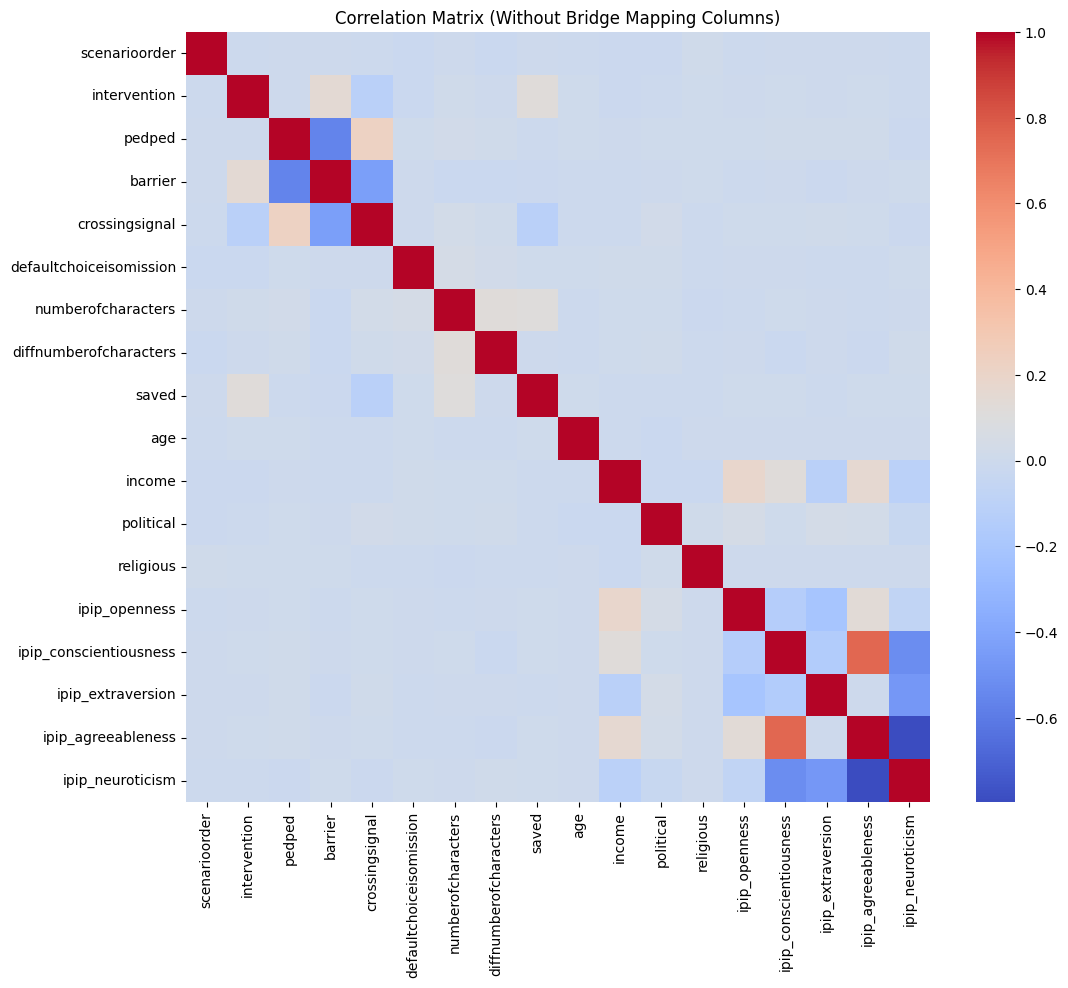

In [8]:
bridge_cols_to_drop = [col for col in merged.columns if col.startswith('bridge_')]

df_final = merged.drop(columns=bridge_cols_to_drop)

df_final = df_final.dropna()

print(f"Dropped {len(bridge_cols_to_drop)} bridge mapping columns.")
print("Dataset shape after polishing:", df_final.shape)

# Display the cleaned dataset
display(df_final.head())

numeric_cols = df_final.select_dtypes(include=['number']).columns
correlation_matrix = df_final[numeric_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Without Bridge Mapping Columns)')
plt.show()

## Section 10 - How Big Five Traits Influence Choices
This section estimates how the Big Five personality traits relate to moral choices (scenario-level). We compute Spearman correlations and fit simple logistic regressions for binary choices, controlling for age and gender where available.

Detected trait columns (trait -> column):
{'openness': 'ipip_openness', 'conscientiousness': 'ipip_conscientiousness', 'extraversion': 'ipip_extraversion', 'agreeableness': 'ipip_agreeableness', 'neuroticism': 'ipip_neuroticism'}
Detected targets: ['saved', 'intervention', 'pedped', 'barrier']


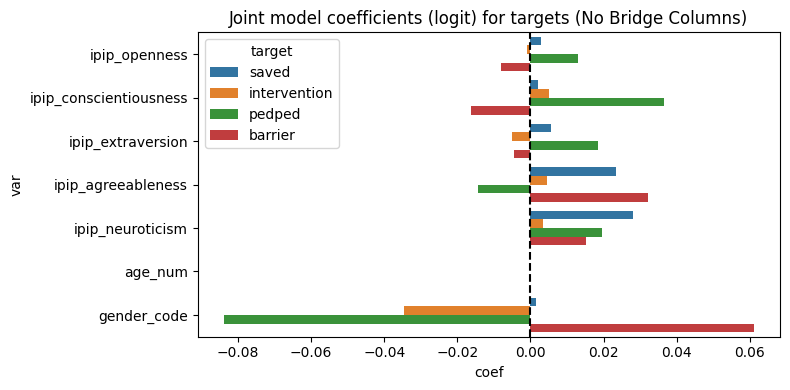

,target,trait,trait_col,n,spearman_rho,spearman_p,logit
0,pedped,conscientiousness,ipip_conscientiousness,11918,0.021436,0.019272,"{'params': {'const': -0.8573903317953365, 'ipi..."
1,intervention,conscientiousness,ipip_conscientiousness,11918,0.015255,0.095863,"{'params': {'const': -0.3947487390055091, 'ipi..."
2,pedped,agreeableness,ipip_agreeableness,11918,0.014731,0.107824,"{'params': {'const': -0.4315180734748922, 'ipi..."
3,pedped,neuroticism,ipip_neuroticism,11918,-0.011475,0.210322,"{'params': {'const': 0.18629839168246728, 'ipi..."
4,barrier,extraversion,ipip_extraversion,11918,-0.011073,0.226781,"{'params': {'const': -0.5841823468324052, 'ipi..."
5,pedped,extraversion,ipip_extraversion,11918,0.010914,0.233521,"{'params': {'const': -0.020932403365656188, 'i..."
6,intervention,agreeableness,ipip_agreeableness,11918,0.010141,0.268288,"{'params': {'const': -0.39884454333567776, 'ip..."
7,saved,openness,ipip_openness,11918,0.008569,0.349598,"{'params': {'const': -0.07244938877797343, 'ip..."
8,barrier,openness,ipip_openness,11918,-0.007144,0.435519,"{'params': {'const': -0.9512185487638732, 'ipi..."
9,saved,neuroticism,ipip_neuroticism,11918,0.006345,0.488549,"{'params': {'const': -0.12082780516729658, 'ip..."


In [9]:
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns

# Detect trait columns 
trait_keys = ['openness','conscientiousness','extraversion','agreeableness','neuroticism']
trait_cols = {}
for t in trait_keys:
    t_lower = t.lower()
    candidates = [c for c in df_final.columns if c.lower() == t_lower or c.lower().endswith('_'+t_lower) or c.lower().startswith('ipip_'+t_lower)]
    if candidates:
        trait_cols[t] = candidates[0]

print('Detected trait columns (trait -> column):')
print(trait_cols)

targets = [c for c in ['saved','intervention','pedped','barrier'] if c in df_final.columns]
print('Detected targets:', targets)

# Prepare gender code and age if available
# Using df_final instead of merged
df_analysis = df_final.copy()

if 'gender' in df_analysis.columns:
    df_analysis['gender_code'] = df_analysis['gender'].astype(str).str.lower().map({'male':1,'female':0}).astype('float')
elif 'mm_gender' in df_analysis.columns:
    df_analysis['gender_code'] = df_analysis['mm_gender'].astype(str).str.lower().map({'male':1,'female':0}).astype('float')

if 'age' in df_analysis.columns:
    df_analysis['age_num'] = pd.to_numeric(df_analysis['age'], errors='coerce')

results = []
for target in targets:
    for trait, col in trait_cols.items():
        sub = df_analysis[[target, col, 'age_num', 'gender_code']].copy()
        sub = sub.dropna(subset=[target, col])
        if len(sub) < 50:
            continue
            
        # Spearman
        try:
            rho, p = spearmanr(sub[col], sub[target], nan_policy='omit')
        except Exception:
            rho, p = (np.nan, np.nan)
            
        # Logistic regression if target is binary (0/1)
        lr_summary = None
        try:
            y = pd.to_numeric(sub[target], errors='coerce')
            if set(y.dropna().unique()) <= {0,1}:
                X = pd.DataFrame()
                X[col] = pd.to_numeric(sub[col], errors='coerce')
                if 'age_num' in sub.columns:
                    X['age_num'] = sub['age_num']
                if 'gender_code' in sub.columns:
                    X['gender_code'] = sub['gender_code']
                X = sm.add_constant(X)
                model = sm.Logit(y, X, missing='drop')
                res = model.fit(disp=False)
                params = res.params.to_dict()
                pvalues = res.pvalues.to_dict()
                odds = np.exp(res.params).to_dict()
                lr_summary = {'params':params, 'pvalues':pvalues, 'odds':odds}
        except Exception as e:
            lr_summary = {'error': str(e)}

        results.append({
            'target': target,
            'trait': trait,
            'trait_col': col,
            'n': len(sub),
            'spearman_rho': float(rho) if not np.isnan(rho) else None,
            'spearman_p': float(p) if not np.isnan(p) else None,
            'logit': lr_summary,
        })

res_df = pd.DataFrame(results).sort_values('spearman_rho', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

# Plot coefficients from joint model (all traits together) for each target
joint_rows = []
for target in targets:
    cols = [trait_cols[t] for t in trait_cols if trait_cols.get(t)]
    use_cols = [c for c in cols if c in df_analysis.columns]
    sub = df_analysis[[target] + use_cols + ['age_num','gender_code']].dropna(subset=[target]+use_cols)
    
    if len(sub) < 100:
        continue
        
    y = pd.to_numeric(sub[target], errors='coerce')
    if not set(y.dropna().unique()) <= {0,1}:
        continue
        
    X = sub[use_cols].apply(pd.to_numeric, errors='coerce')
    if 'age_num' in sub.columns:
        X['age_num'] = sub['age_num']
    if 'gender_code' in sub.columns:
        X['gender_code'] = sub['gender_code']
        
    X = sm.add_constant(X)
    try:
        res = sm.Logit(y, X, missing='drop').fit(disp=False)
        params = res.params
        pvals = res.pvalues
        orrs = np.exp(params)
        for name in params.index:
            if name == 'const':
                continue
            joint_rows.append({'target': target, 'var': name, 'coef': params[name], 'p': pvals[name], 'odds': orrs[name]})
    except Exception:
        continue

joint_df = pd.DataFrame(joint_rows)
if not joint_df.empty:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, max(4, joint_df['var'].nunique()*0.5)))
    sns.barplot(data=joint_df, x='coef', y='var', hue='target')
    plt.axvline(0, color='k', linestyle='--')
    plt.title('Joint model coefficients (logit) for targets (No Bridge Columns)')
    plt.tight_layout()
    plt.show()

# Show top correlations table
display(res_df.head(40))

## Section 11 - Modeling: Predicting Choices from Personality + Scenario
This section builds a scenario-level prediction pipeline using Big Five traits + demographics + scenario attributes. It compares Logistic Regression, Random Forest, and HistGradientBoosting using cross-validation, then fits the best model on a user-grouped train/test split and reports standard metrics (accuracy, precision, recall, F1, ROC-AUC, AP, Brier, confusion matrix).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

TARGET = 'saved'

# Define Features (X) and Target (y)
cols_to_drop = [TARGET, 'user_id', 'scenarioorder']
X = df_final.drop(columns=cols_to_drop, errors='ignore')
y = df_final[TARGET]

# Separate columns into Numeric and Categorical
categorical_cols = ['scenariotype', 'country', 'gender', 'education', 'income']
categorical_cols = [c for c in categorical_cols if c in X.columns]

numeric_cols = [c for c in X.columns if c not in categorical_cols]

# - Standardizes numeric features (like age and personality scores)
# - One-Hot Encodes categorical features (like scenariotype and country)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

best_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1))
])

# Split, Train, and Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training model...")
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

# View Results
acc = accuracy_score(y_test, y_pred)
print(f"New Model Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training model...
New Model Accuracy: 0.6997

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.64      0.68      1178
           1       0.68      0.76      0.72      1206

    accuracy                           0.70      2384
   macro avg       0.70      0.70      0.70      2384
weighted avg       0.70      0.70      0.70      2384



## Section 12 - Manual Testing


In [ ]:
# Complete your results here
my_real_profile = {
    'ipip_openness': 4.3, 'ipip_conscientiousness': 4.1, 'ipip_extraversion': 1.8,
    'ipip_agreeableness': 4.5, 'ipip_neuroticism': 1.6, 'age_num': 25, 'gender_code': 1
}

scenarii_unice = {
    "1. Gen (Gender)": {
        'scenariotype': 'Gender', 'defaultchoice': 'Male', 'nondefaultchoice': 'Female',
        'numberofcharacters': 2, 'diffnumberofcharacters': 0, 'barrier': 0, 'crossingsignal': 0
    },
    "2. Condiție Fizică (Fitness)": {
        'scenariotype': 'Fitness', 'defaultchoice': 'Fit', 'nondefaultchoice': 'Fat',
        'numberofcharacters': 2, 'diffnumberofcharacters': 0, 'barrier': 0, 'crossingsignal': 0
    },
    "3. Vârstă (Age)": {
        'scenariotype': 'Age', 'defaultchoice': 'Young', 'nondefaultchoice': 'Old',
        'numberofcharacters': 2, 'diffnumberofcharacters': 0, 'barrier': 0, 'crossingsignal': 2
    },
    "4. Specie (Species)": {
        'scenariotype': 'Species', 'defaultchoice': 'Hoomans', 'nondefaultchoice': 'Pets',
        'numberofcharacters': 3, 'diffnumberofcharacters': 0, 'barrier': 0, 'crossingsignal': 2
    },
    "5. Utilitarian (Cantitate)": {
        'scenariotype': 'Utilitarian', 'defaultchoice': 'Grup Mare (5)', 'nondefaultchoice': 'Grup Mic (3)',
        'numberofcharacters': 5, 'diffnumberofcharacters': 2, 'barrier': 0, 'crossingsignal': 1
    },
    "6. Sacrificiu Pasager (Barrier)": {
        'scenariotype': 'Utilitarian', 'defaultchoice': 'Pietoni', 'nondefaultchoice': 'Pasageri',
        'numberofcharacters': 1, 'diffnumberofcharacters': 0, 'barrier': 1, 'crossingsignal': 1
    },
    "7. Aleatoriu (Random)": {
        'scenariotype': 'Random', 'defaultchoice': 'Persoana A', 'nondefaultchoice': 'Persoana B',
        'numberofcharacters': 1, 'diffnumberofcharacters': 0, 'barrier': 0, 'crossingsignal': 1
    }
}

print("=== REZULTATE PREDICȚIE MODEL (VALORI BINARE INCLUSE) ===\n")

for nume, detalii in scenarii_unice.items():
    try:
        count_def = detalii['numberofcharacters']
        count_non_def = count_def - detalii['diffnumberofcharacters']
        
        print(f"📌 {nume}")
        print(f"   ◦ Inacțiune: Mașina lovește {count_def} x [{detalii['defaultchoice']}]")
        print(f"   ◦ Viraj: Mașina lovește {count_non_def} x [{detalii['nondefaultchoice']}]")
        
        if detalii['crossingsignal'] == 2:
            print("   ⚠️ Notă: Grupul aflat pe traiectorie traversează pe ROȘU.")
        if detalii['barrier'] == 1:
            print("   🛡️ Notă: Virajul implică izbirea de un zid (sacrificiu pasageri).")

        res, probs = get_model_prediction(my_real_profile, detalii)
        
        if res == 1:
            decizie_text = f"SALVEAZĂ {detalii['defaultchoice']}"
        else:
            decizie_text = f"SALVEAZĂ {detalii['nondefaultchoice']}"
            
        print(f"   🤖 DECIZIE: {decizie_text} (Predicție brută: {res})")
        print(f"   📊 Siguranță model: {max(probs)*100:.2f}%")
        print("-" * 55 + "\n")

    except Exception as e:
        print(f"❌ Eroare la {nume}: {e}")

=== REZULTATE PREDICȚIE MODEL (VALORI BINARE INCLUSE) ===

📌 1. Gen (Gender)
   ◦ Inacțiune: Mașina lovește 2 x [Male]
   ◦ Viraj: Mașina lovește 2 x [Female]
   🤖 DECIZIE: SALVEAZĂ Male (Predicție brută: 1)
   📊 Siguranță model: 50.68%
-------------------------------------------------------

📌 2. Condiție Fizică (Fitness)
   ◦ Inacțiune: Mașina lovește 2 x [Fit]
   ◦ Viraj: Mașina lovește 2 x [Fat]
   🤖 DECIZIE: SALVEAZĂ Fat (Predicție brută: 0)
   📊 Siguranță model: 52.10%
-------------------------------------------------------

📌 3. Vârstă (Age)
   ◦ Inacțiune: Mașina lovește 2 x [Young]
   ◦ Viraj: Mașina lovește 2 x [Old]
   ⚠️ Notă: Grupul aflat pe traiectorie traversează pe ROȘU.
   🤖 DECIZIE: SALVEAZĂ Old (Predicție brută: 0)
   📊 Siguranță model: 54.67%
-------------------------------------------------------

📌 4. Specie (Species)
   ◦ Inacțiune: Mașina lovește 3 x [Hoomans]
   ◦ Viraj: Mașina lovește 3 x [Pets]
   ⚠️ Notă: Grupul aflat pe traiectorie traversează pe ROȘU.
   🤖